In [2]:
# Libraries
import yfinance as yf
import talib as ta

import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('default')
%matplotlib inline
from mplfinance.original_flavor import candlestick_ohlc
import matplotlib.dates as mpdates


The outcome of the print statement is Python dictionary, which we can parse in order to extract the desired financial data from Yahoo Finance. For instance, let's extract a few financial key metrics.
All company information is contained under the info dictionary. Therefor, we can parse the dictionary to extract the elements that we are interested in

In [3]:
# KLCI History
df_KLCI = pd.read_csv('KLCI_Historical_Data.csv', header=[0, 1], skiprows=1)

# Flatten multi-level headers
df_KLCI.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_KLCI.columns.values]

# Rename the first column to 'Date'
df_KLCI = df_KLCI.rename(columns={df_KLCI.columns[0]: 'Date'})

# Convert 'Date' column to datetime format
df_KLCI['Date'] = pd.to_datetime(df_KLCI['Date'], errors='coerce')
#df_KLCI = df_KLCI.set_index('Date')

# flatten multi-level
#df_KLCI.columns = df_KLCI.columns.to_flat_index().map(lambda x: '_'.join(map(str, x)))


In [4]:
# Rename the columns in df_KLCI
df_KLCI = df_KLCI.rename(columns={
    '^KLSE_Unnamed: 1_level_1': 'Close',
    '^KLSE_Unnamed: 2_level_1': 'High',
    '^KLSE_Unnamed: 3_level_1': 'Low',
    '^KLSE_Unnamed: 4_level_1': 'Open',
    '^KLSE_Unnamed: 5_level_1': 'Volume'
})

df_KLCI

,Date,Close,High,Low,Open,Volume
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900
...,...,...,...,...,...,...
1465,2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400
1466,2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600
1467,2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200
1468,2024-12-30,1637.680054,1638.560059,1624.920044,1626.140015,134711300


In [5]:
df_KLCI.columns = df_KLCI.columns.get_level_values(0)


In [6]:
df_KLCI.index.name  # should return 'Date'


In [7]:
df_KLCI

,Date,Close,High,Low,Open,Volume
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900
...,...,...,...,...,...,...
1465,2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400
1466,2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600
1467,2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200
1468,2024-12-30,1637.680054,1638.560059,1624.920044,1626.140015,134711300


In [8]:
df_KLCI

,Date,Close,High,Low,Open,Volume
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900
...,...,...,...,...,...,...
1465,2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400
1466,2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600
1467,2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200
1468,2024-12-30,1637.680054,1638.560059,1624.920044,1626.140015,134711300


C:\Users\badar\AppData\Local\Temp\ipykernel_7908\3426818515.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_KLCI['Date'] = pd.to_datetime(df_KLCI['Date'])
C:\Users\badar\AppData\Local\Temp\ipykernel_7908\3426818515.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_KLCI['Date'] = df_KLCI['Date'].map(mpdates.date2num)


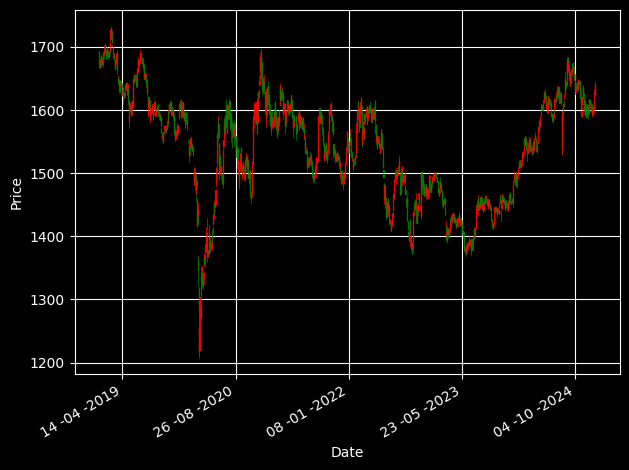

In [ ]:
plt.style.use('dark_background')

# extracting Data for plotting
df_KLCI = df_KLCI[['Date', 'Close', 'High', 'Low', 'Open']]

# convert into datetime object
df_KLCI['Date'] = pd.to_datetime(df_KLCI['Date'])

# apply map function
df_KLCI['Date'] = df_KLCI['Date'].map(mpdates.date2num)

# creating Subplots
fig, ax = plt.subplots()

# plotting the data 
candlestick_ohlc(ax, df_KLCI.values, width =0.6, 
                colorup = 'green', colordown = 'red',
                alpha = 0.8)

# allow grid
ax.grid (True)

# setting labels 
ax.set_xlabel('Date')
ax.set_ylabel('Price')

# Formatting Date
date_format = mpdates.DateFormatter('%d -%m -%Y')
ax.xaxis.set_major_formatter(date_format)
fig.autofmt_xdate()

fig.tight_layout()

# show the plot 
plt.show()

Simple Moving Average (SMA)
A simple moving average tells us the unweighted mean of the previous K data points. The more the value of K the more smooth is the curve, but increasing K decreases accuracy

To calculate SMA in Python we will use Pandas dataframe.rolling() function that helps us to make calculations on a rolling window. On the rolling window, we will use .mean() function to calculate the mean of each window.

Syntax: DataFrame.rolling(window, min_periods=None, center=False, win_type=None, on=None, axis=0).mean()

Parameters : window: Size of the window. That is how many observations we have to take for the calculation of each window.

min_periods: Least number of observations in a window required to have a value (otherwise result is NA).

center: It is used to set the labels at the center of the window.

win_type: It is used to set the window type.

on: Datetime column of our dataframe on which we have to calculate rolling mean.

axis: ineger or string, default 0

In [10]:
# Check the columns
print(df_KLCI.columns)
print(df_KLCI.index)

Index(['Date', 'Close', 'High', 'Low', 'Open'], dtype='object')
RangeIndex(start=0, stop=1470, step=1)


In [11]:
df_KLCI.set_index('Date', inplace=True)


In [12]:
# extract 'Close' and calculate SMA while keeping the Date index
df_indexed = df_KLCI[['Close']].copy()
df_indexed['SMA30'] = df_indexed['Close'].rolling(30).mean()

In [13]:
# removing all the NULL values using dropna() method
df_indexed.dropna(inplace=True)
df_indexed


,Close,SMA30
Date,,
17945.0,1692.739990,1684.509338
17946.0,1706.560059,1685.791007
17947.0,1726.180054,1687.469344
17948.0,1730.680054,1689.499345
17949.0,1721.420044,1690.907678
...,...,...
20081.0,1602.989990,1601.952327
20083.0,1613.699951,1602.025659
20084.0,1628.140015,1602.940991


In [14]:
df_indexed.index = pd.to_datetime(pd.to_datetime('1970-01-01') + pd.to_timedelta(df_indexed.index, unit ='D'))

<Axes: xlabel='Date'>

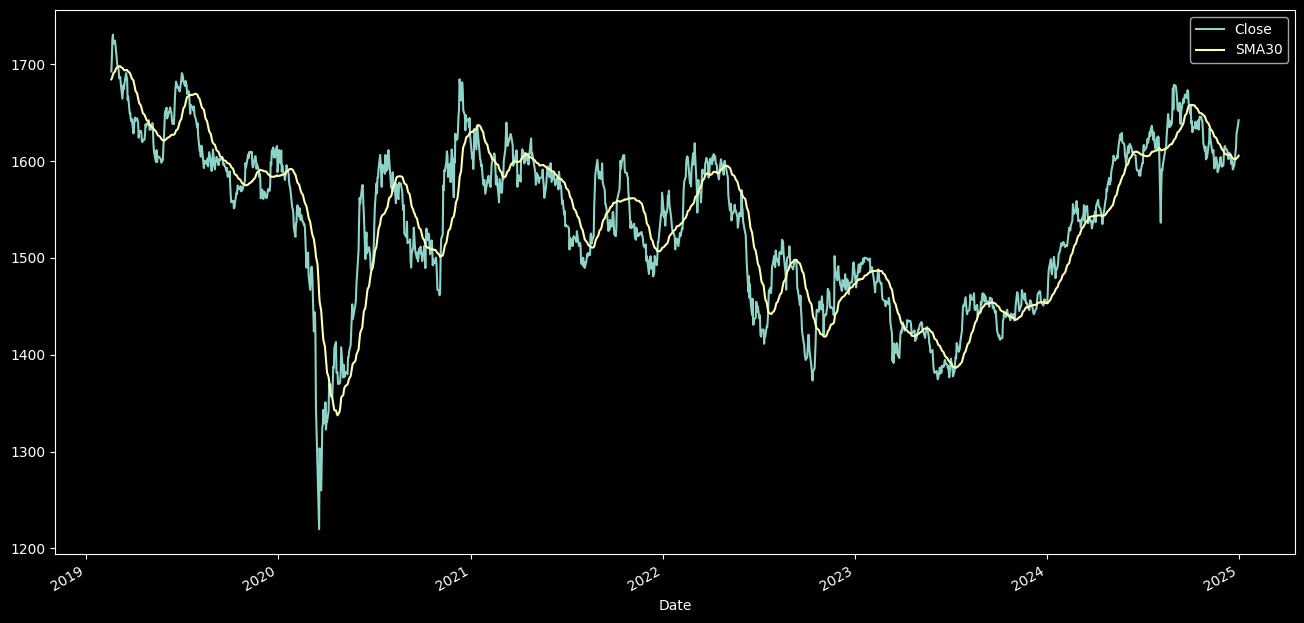

In [15]:
df_indexed[['Close', 'SMA30']].plot(label ='KLCI', figsize =(16,8))

Exponential Moving Average (EMA): Exponential moving average (EMA) tells us the weighted mean of the previous K data points. EMA places a greater weight and significance on the most recent data points.

In [16]:
df_indexed = df_indexed['Close'].to_frame()

# calculating exponential moving average
#using.ewm(span).mean(), with window size = 30

df_indexed['EWMA30'] = df_indexed['Close'].ewm(span=30).mean()

# printing Dataframe
df_indexed

,Close,EWMA30
Date,,
2019-02-18,1692.739990,1692.739990
2019-02-19,1706.560059,1699.880359
2019-02-20,1726.180054,1709.237636
2019-02-21,1730.680054,1715.145804
2019-02-22,1721.420044,1716.573345
...,...,...
2024-12-24,1602.989990,1605.561868
2024-12-26,1613.699951,1606.086906
2024-12-27,1628.140015,1607.509687


<Axes: xlabel='Date'>

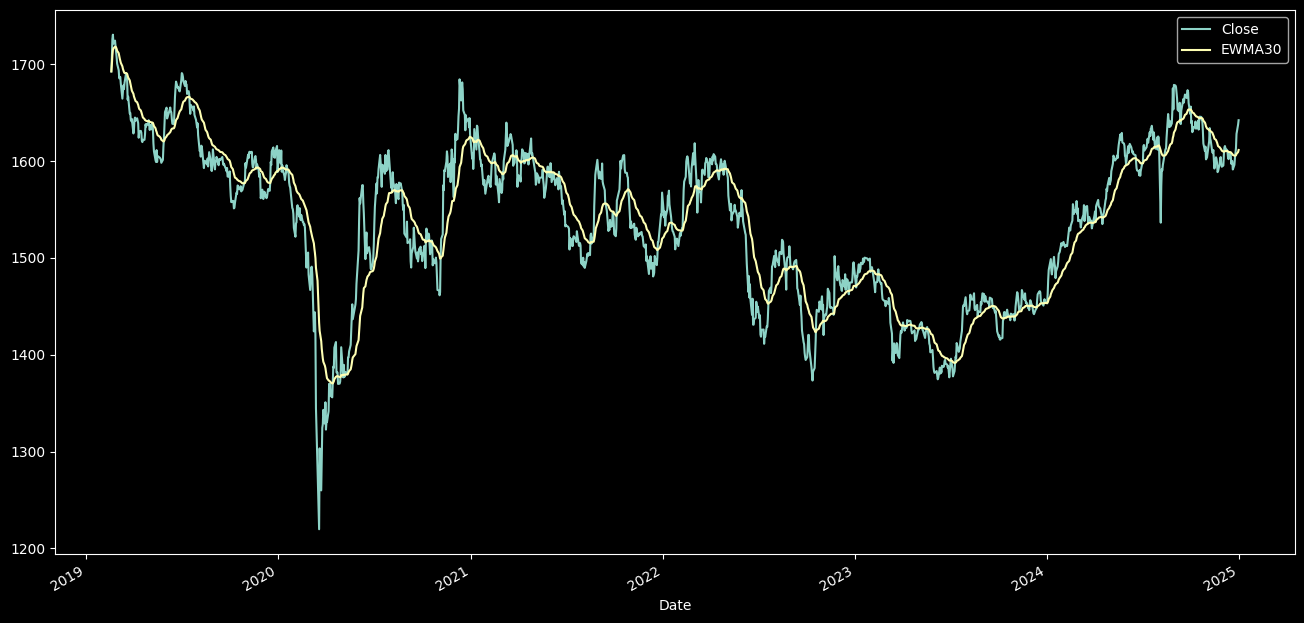

In [17]:
# plotting Close price and exponential
# moving averages of 30 days
# using.plot() method

df_indexed[['Close', 'EWMA30']].plot(label='KLCI', figsize=(16, 8))


In [18]:
# technical analysis
# creating new column 'diff' in DataFrame by subtracting 'Close' column from 'Open' column
df_KLCI['diff'] = df_KLCI['Open'] - df_KLCI['Close']

C:\Users\badar\AppData\Local\Temp\ipykernel_7908\889277753.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_KLCI['diff'] = df_KLCI['Open'] - df_KLCI['Close']


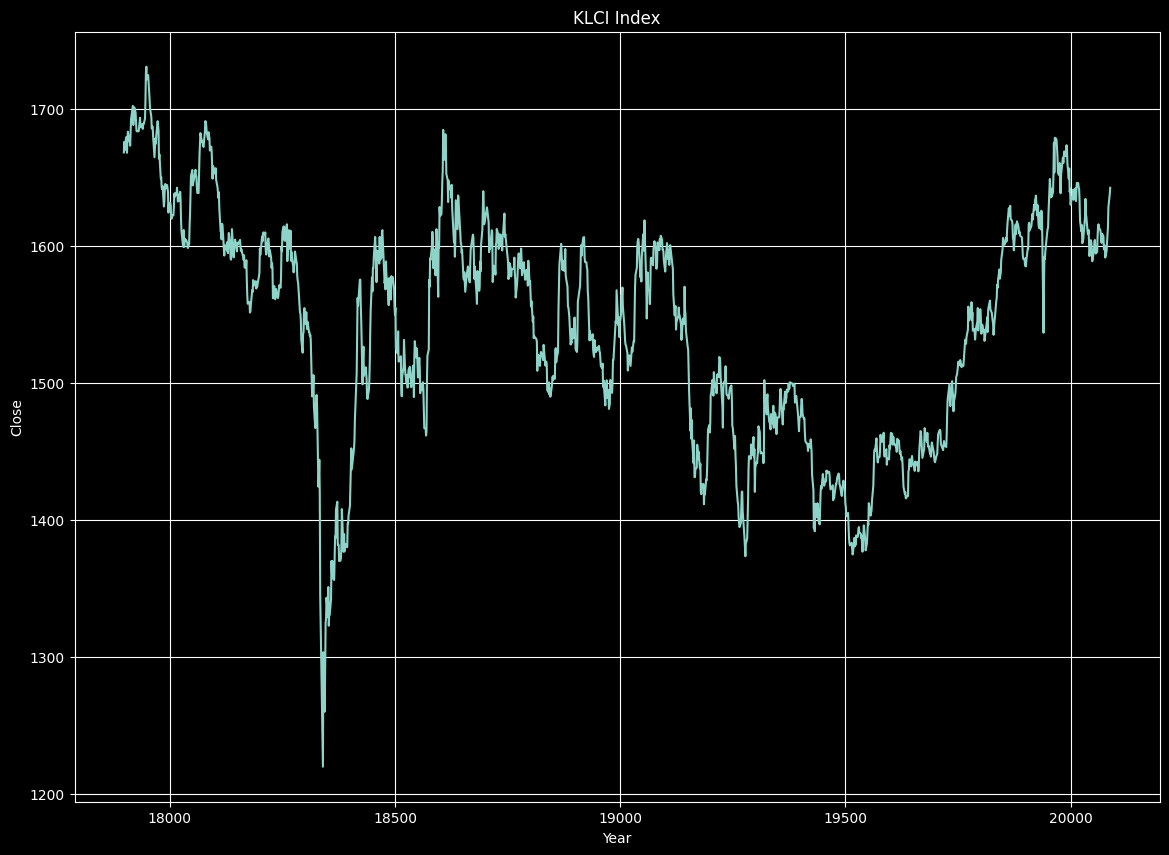

In [19]:
# import matplotplib.pyplot as plt
# plot the closing price of KLCI
plt.figure(figsize=(14,10))
plt.plot(df_KLCI['Close'])
plt.grid()
plt.xlabel('Year')
plt.ylabel('Close')
plt.title('KLCI Index')
plt.show()